In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
DATA_PATH = Path("../data/processed/cleaned_grading_dataset.xlsx")

df = pd.read_excel(DATA_PATH)

print(f"Shape: {df.shape}")

Shape: (1055, 116)


In [3]:
df.head()

,Tissue_ID,Eye,Image_ID,Disease_Label,Disease_Severity,ECD_CD_cells_per_mm2,CV,HEX_percent,SD,Total_Cell_Count,...,Epi_Has_Exposure,Epi_Exposure_Severity,Epi_Has_Defect,Epi_Has_Haze,Epi_Haze_Severity,Epi_Exposure_Location,Epi_Has_Arcus,Donor_Graft_Size_Clean_mm,Recipient_Bed_Size_Clean_mm,Previous_Grafts_Clean
0,12346 R (year/month unknown),Right,NaN,Normal,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NEB-2020-09-12654 R,Right,NEB-2020-09-12654 R_SP,Normal,NaN,2132.0,33.0,58.0,153.0,24.0,...,0.0,NaN,0.0,0.0,NaN,NaN,0.0,8.25,8.0,NaN
2,NEB-2020-09-12655 L,Left,NEB-2020-09-12655 L_SP,Folds,Moderate,2212.0,33.0,47.0,147.0,70.0,...,1.0,Mild,0.0,0.0,NaN,Peripheral,0.0,NaN,NaN,NaN
3,NEB-2020-09-12656 R,Right,NEB-2020-09-12656 R_SP,Normal,NaN,2538.0,35.0,53.0,137.0,136.0,...,0.0,NaN,0.0,0.0,NaN,NaN,0.0,NaN,NaN,1
4,NEB-2020-09-12657 L,Left,NEB-2020-09-12657 L_SP,Folds,Mild,2584.0,29.0,69.0,112.0,115.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.5,2


In [5]:
print(df["Tissue_Grade_Clean"].value_counts(dropna=False))

Tissue_Grade_Clean
A+     545
A      319
B      172
NaN     19
Name: count, dtype: int64


In [7]:
target_counts = (
    df["Tissue_Grade_Clean"]
    .value_counts(dropna=False)
    .rename_axis("Grade")
    .reset_index(name="Count")
)

target_counts["Percentage"] = (
    target_counts["Count"] / len(df) * 100
).round(2)

print(target_counts)

  Grade  Count  Percentage
0    A+    545       51.66
1     A    319       30.24
2     B    172       16.30
3   NaN     19        1.80


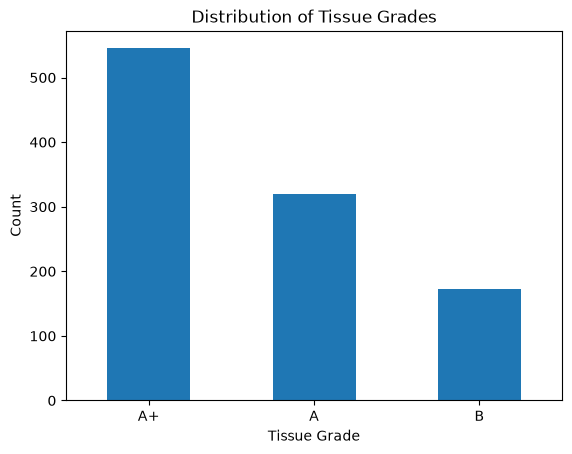

In [8]:
plot_data = (
    df["Tissue_Grade_Clean"]
    .value_counts()
    .reindex(["A+", "A", "B"])
)

plot_data.plot(kind="bar")

plt.title("Distribution of Tissue Grades")
plt.xlabel("Tissue Grade")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [9]:
numeric_features = [
    "ECD_CD_cells_per_mm2",
    "CV",
    "HEX_percent",
    "SD",
    "Total_Cell_Count",
    "Total_Area_um2",
    "Donor_Age",
]

numeric_by_grade = (
    df[df["Tissue_Grade_Clean"].notna()]
    .groupby("Tissue_Grade_Clean")[numeric_features]
    .agg(["count", "mean", "median", "std"])
)

print(numeric_by_grade)

                   ECD_CD_cells_per_mm2                                   \
                                  count         mean  median         std   
Tissue_Grade_Clean                                                         
A                                   281  2533.583630  2415.0  341.467067   
A+                                  505  2813.380198  2762.0  258.603772   
B                                   154  1944.110390  2024.0  378.747326   

                      CV                             HEX_percent             \
                   count       mean median       std       count       mean   
Tissue_Grade_Clean                                                            
A                    281  38.822064   38.0  5.064267         281  52.302491   
A+                   505  37.465347   37.0  4.224279         505  55.269307   
B                    154  39.201299   38.0  6.630667         154  53.097403   

                    ... Total_Cell_Count            Total_Area_um2  

In [10]:
pd.set_option("display.max_columns", None)

print(numeric_by_grade)

                   ECD_CD_cells_per_mm2                                   \
                                  count         mean  median         std   
Tissue_Grade_Clean                                                         
A                                   281  2533.583630  2415.0  341.467067   
A+                                  505  2813.380198  2762.0  258.603772   
B                                   154  1944.110390  2024.0  378.747326   

                      CV                             HEX_percent             \
                   count       mean median       std       count       mean   
Tissue_Grade_Clean                                                            
A                    281  38.822064   38.0  5.064267         281  52.302491   
A+                   505  37.465347   37.0  4.224279         505  55.269307   
B                    154  39.201299   38.0  6.630667         154  53.097403   

                                       SD                           

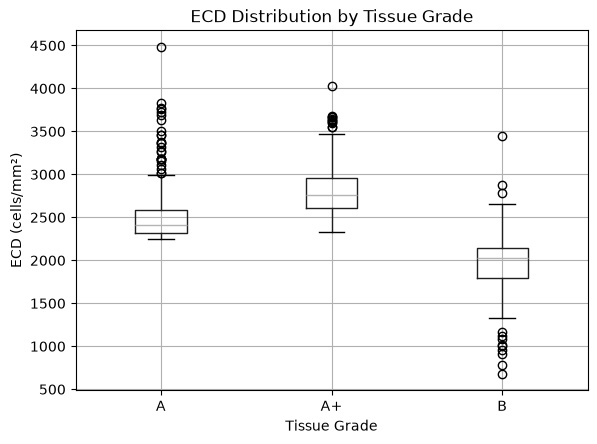

In [11]:
plot_df = df[
    df["Tissue_Grade_Clean"].notna()
][["Tissue_Grade_Clean", "ECD_CD_cells_per_mm2"]].dropna()

plot_df.boxplot(
    column="ECD_CD_cells_per_mm2",
    by="Tissue_Grade_Clean"
)

plt.title("ECD Distribution by Tissue Grade")
plt.suptitle("")
plt.xlabel("Tissue Grade")
plt.ylabel("ECD (cells/mm²)")
plt.show()

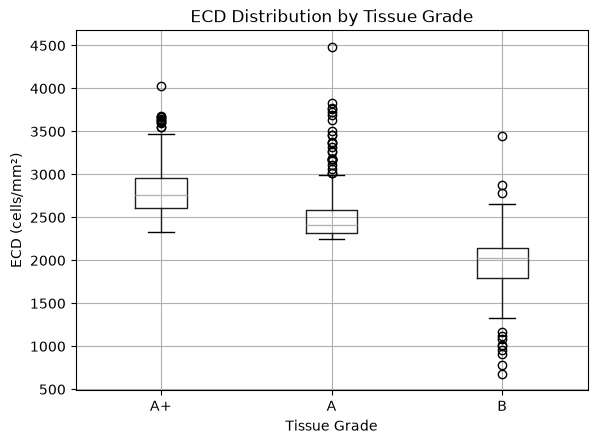

In [12]:
plot_df = df[
    df["Tissue_Grade_Clean"].notna()
][["Tissue_Grade_Clean", "ECD_CD_cells_per_mm2"]].dropna()

plot_df["Tissue_Grade_Clean"] = pd.Categorical(
    plot_df["Tissue_Grade_Clean"],
    categories=["A+", "A", "B"],
    ordered=True
)

plot_df.boxplot(
    column="ECD_CD_cells_per_mm2",
    by="Tissue_Grade_Clean"
)

plt.title("ECD Distribution by Tissue Grade")
plt.suptitle("")
plt.xlabel("Tissue Grade")
plt.ylabel("ECD (cells/mm²)")
plt.show()

In [13]:
def ecd_rule_grade(ecd):
    if pd.isna(ecd):
        return pd.NA
    if ecd > 3000:
        return "A+"
    if 2500 <= ecd <= 3000:
        return "A"
    if 2000 <= ecd < 2500:
        return "B"
    return pd.NA


df["ECD_Rule_Grade"] = df["ECD_CD_cells_per_mm2"].apply(ecd_rule_grade)

In [15]:
print(pd.crosstab(
    df["Tissue_Grade_Clean"],
    df["ECD_Rule_Grade"],
    dropna=False
))

ECD_Rule_Grade        A   A+    B  NaN
Tissue_Grade_Clean                    
A                    75   25  181   38
A+                  397  106    2   40
B                     5    1   86   80
NaN                   3    6    3    7


In [17]:
comparison = df[
    df["Tissue_Grade_Clean"].notna()
].copy()

comparison["ECD_Rule_Match"] = (
    comparison["Tissue_Grade_Clean"]
    == comparison["ECD_Rule_Grade"]
)

print(comparison["ECD_Rule_Match"].value_counts(dropna=False))

ECD_Rule_Match
False    769
True     267
Name: count, dtype: int64


In [18]:
rule_evaluable = comparison[
    comparison["ECD_Rule_Grade"].notna()
]

print("Evaluable records:", len(rule_evaluable))

print(
    "ECD rule agreement:",
    round(
        rule_evaluable["ECD_Rule_Match"].mean() * 100,
        2
    ),
    "%"
)

Evaluable records: 878
ECD rule agreement: 30.41 %


In [20]:
grade_agreement = (
    rule_evaluable
    .groupby("Tissue_Grade_Clean")["ECD_Rule_Match"]
    .agg(["count", "sum", "mean"])
)

grade_agreement["Agreement_Percent"] = (
    grade_agreement["mean"] * 100
).round(2)

print(grade_agreement)

                    count  sum      mean  Agreement_Percent
Tissue_Grade_Clean                                         
A                     281   75  0.266904              26.69
A+                    505  106  0.209901              20.99
B                      92   86  0.934783              93.48


In [21]:
discordant = rule_evaluable[
    ~rule_evaluable["ECD_Rule_Match"]
].copy()

print("Discordant cases:", len(discordant))

Discordant cases: 611


In [23]:
print(pd.crosstab(
    discordant["Tissue_Grade_Clean"],
    discordant["ECD_Rule_Grade"]
))

ECD_Rule_Grade        A  A+    B
Tissue_Grade_Clean              
A                     0  25  181
A+                  397   0    2
B                     5   1    0


In [25]:
print(discordant[
    [
        "Tissue_Grade_Clean",
        "ECD_Rule_Grade",
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent",
        "SD",
        "Total_Cell_Count",
        "Total_Area_um2",
        "Donor_Age",
    ]
].groupby(
    ["Tissue_Grade_Clean", "ECD_Rule_Grade"]
).agg(["count", "mean", "median"]))

                                  ECD_CD_cells_per_mm2                       \
                                                 count         mean  median   
Tissue_Grade_Clean ECD_Rule_Grade                                             
A                  A+                               25  3414.200000  3367.0   
                   B                               181  2348.209945  2336.0   
A+                 A                               397  2711.000000  2695.0   
                   B                                 2  2373.500000  2373.5   
B                  A                                 5  2697.800000  2653.0   
                   A+                                1  3448.000000  3448.0   

                                     CV                   HEX_percent  \
                                  count       mean median       count   
Tissue_Grade_Clean ECD_Rule_Grade                                       
A                  A+                25  41.880000   41.0          25

In [27]:
discordance_summary = (
    rule_evaluable
    .assign(
        ECD_Discordant=~rule_evaluable["ECD_Rule_Match"]
    )
    .groupby("ECD_Discordant")[
        [
            "ECD_CD_cells_per_mm2",
            "CV",
            "HEX_percent",
            "SD",
            "Total_Cell_Count",
            "Total_Area_um2",
            "Donor_Age",
        ]
    ]
    .agg(["count", "mean", "median"])
)

print(discordance_summary)

               ECD_CD_cells_per_mm2                         CV             \
                              count         mean  median count       mean   
ECD_Discordant                                                              
False                           267  2710.606742  2732.0   267  38.288390   
True                            611  2632.294599  2597.0   611  37.890344   

                      HEX_percent                      SD                     \
               median       count       mean median count        mean median   
ECD_Discordant                                                                 
False            38.0         267  53.183521   53.0   267  145.883895  141.0   
True             38.0         611  54.466448   54.0   611  145.306056  144.0   

               Total_Cell_Count                    Total_Area_um2  \
                          count        mean median          count   
ECD_Discordant                                                      
False 

In [28]:
a_plus_as_a = rule_evaluable[
    (rule_evaluable["Tissue_Grade_Clean"] == "A+") &
    (rule_evaluable["ECD_Rule_Grade"] == "A")
].copy()

In [29]:
a_plus_correct = rule_evaluable[
    (rule_evaluable["Tissue_Grade_Clean"] == "A+") &
    (rule_evaluable["ECD_Rule_Grade"] == "A+")
].copy()

In [30]:
a_plus_comparison = pd.DataFrame({
    "A+ specialist / ECD=A": a_plus_as_a[
        [
            "ECD_CD_cells_per_mm2",
            "CV",
            "HEX_percent",
            "SD",
            "Total_Cell_Count",
            "Total_Area_um2",
            "Donor_Age",
        ]
    ].mean(),

    "A+ specialist / ECD=A+": a_plus_correct[
        [
            "ECD_CD_cells_per_mm2",
            "CV",
            "HEX_percent",
            "SD",
            "Total_Cell_Count",
            "Total_Area_um2",
            "Donor_Age",
        ]
    ].mean(),
})

print(a_plus_comparison)

                      A+ specialist / ECD=A  A+ specialist / ECD=A+
ECD_CD_cells_per_mm2            2711.000000             3205.122642
CV                                37.370277               37.754717
HEX_percent                       55.307305               55.254717
SD                               138.251889              117.849057
Total_Cell_Count                 109.060453              111.292453
Total_Area_um2                 40369.158690            34847.169811
Donor_Age                         58.272727               55.209524


In [5]:
numeric_features = [
    "ECD_CD_cells_per_mm2",
    "CV",
    "HEX_percent",
    "SD",
    "Total_Cell_Count",
    "Total_Area_um2",
    "Donor_Age",
]

grade_feature_summary = (
    df[df["Tissue_Grade_Clean"].isin(["A+", "A", "B"])]
    .groupby("Tissue_Grade_Clean")[numeric_features]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print(grade_feature_summary)

                   ECD_CD_cells_per_mm2                             CV         \
                                  count     mean  median     std count   mean   
Tissue_Grade_Clean                                                              
A                                   281  2533.58  2415.0  341.47   281  38.82   
A+                                  505  2813.38  2762.0  258.60   505  37.47   
B                                   154  1944.11  2024.0  378.75   154  39.20   

                                HEX_percent         ... Total_Cell_Count  \
                   median   std       count   mean  ...           median   
Tissue_Grade_Clean                                  ...                    
A                    38.0  5.06         281  52.30  ...            108.0   
A+                   37.0  4.22         505  55.27  ...            108.0   
B                    38.0  6.63         154  53.10  ...            104.0   

                          Total_Area_um2                

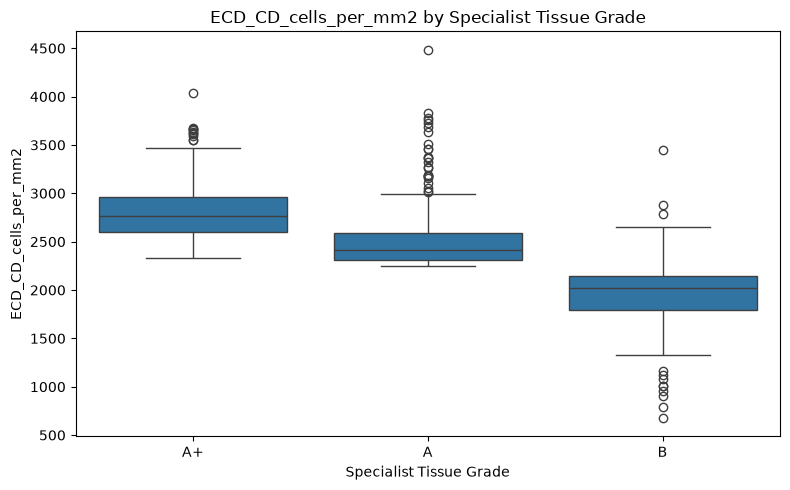

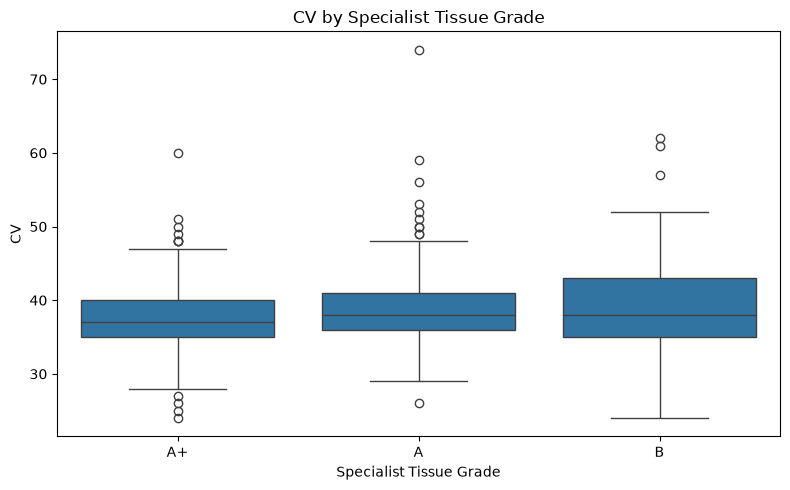

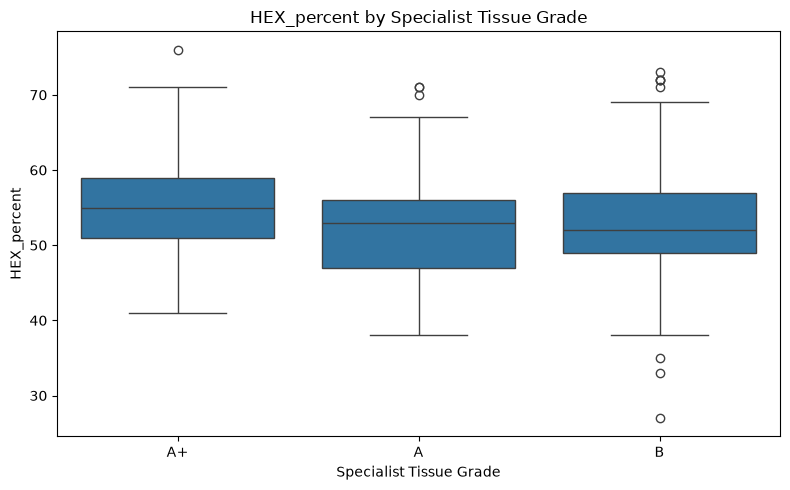

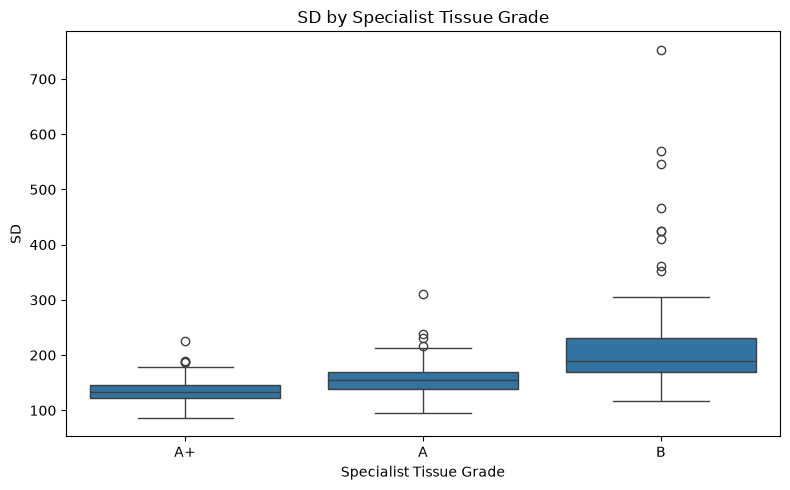

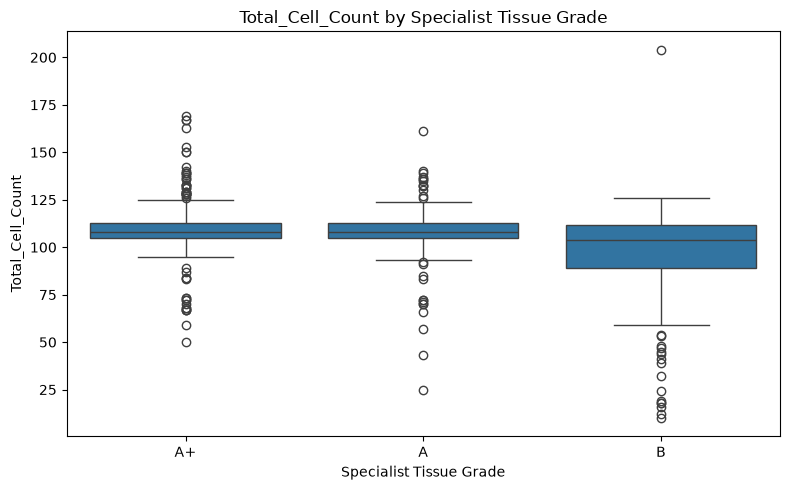

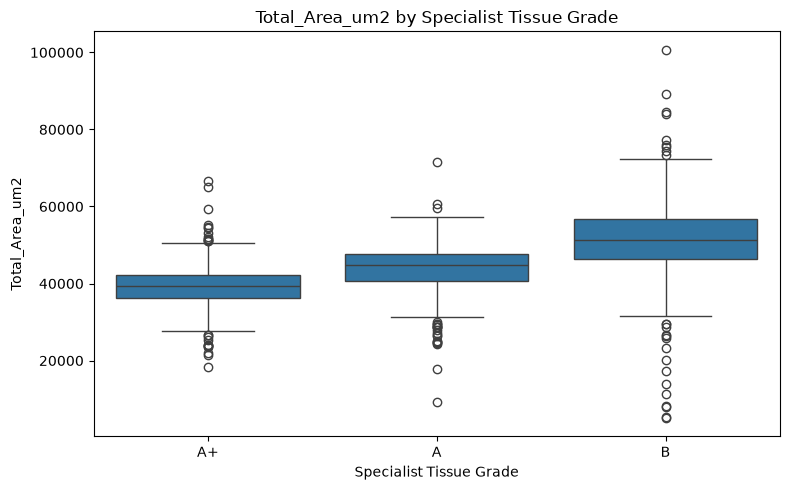

In [6]:

import matplotlib.pyplot as plt
import seaborn as sns

numeric_features = [
    "ECD_CD_cells_per_mm2",
    "CV",
    "HEX_percent",
    "SD",
    "Total_Cell_Count",
    "Total_Area_um2",
]

grade_order = ["A+", "A", "B"]

eda_df = df[
    df["Tissue_Grade_Clean"].isin(grade_order)
].copy()

for feature in numeric_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=eda_df,
        x="Tissue_Grade_Clean",
        y=feature,
        order=grade_order,
    )

    plt.title(f"{feature} by Specialist Tissue Grade")
    plt.xlabel("Specialist Tissue Grade")
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()


In [7]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

clinical_features = [
    "Stroma_Is_Clear",
    "Stroma_Has_Edema",
    "Stroma_Has_Scar",
    "Descemet_Has_Folds",
    "Endo_Has_Cell_Dropout",
    "Endo_Has_Stress_Lines",
    "Epi_Has_Defect",
    "Epi_Has_Haze",
]

clinical_df = df[
    df["Tissue_Grade_Clean"].isin(["A+", "A", "B"])
].copy()

for feature in clinical_features:
    print(f"\n{feature}")

    counts = pd.crosstab(
        clinical_df["Tissue_Grade_Clean"],
        clinical_df[feature],
        dropna=False,
    )

    print(counts)



Stroma_Is_Clear
Stroma_Is_Clear     0.0  1.0  NaN
Tissue_Grade_Clean               
A                     2  198  119
A+                    5  284  256
B                     2   82   88

Stroma_Has_Edema
Stroma_Has_Edema    0.0  1.0  NaN
Tissue_Grade_Clean               
A                   196    4  119
A+                  284    5  256
B                    83    1   88

Stroma_Has_Scar
Stroma_Has_Scar     0.0  1.0  NaN
Tissue_Grade_Clean               
A                   188   12  119
A+                  289    0  256
B                    63   21   88

Descemet_Has_Folds
Descemet_Has_Folds  0.0  1.0  NaN
Tissue_Grade_Clean               
A                     3  179  137
A+                    2  268  275
B                     1   76   95

Endo_Has_Cell_Dropout
Endo_Has_Cell_Dropout  0.0  1.0  NaN
Tissue_Grade_Clean                  
A                      165   34  120
A+                     240   43  262
B                       65   14   93

Endo_Has_Stress_Lines
Endo_Has_Stress_L

In [9]:

import pandas as pd

# Recreate the ECD rule
def ecd_rule_grade(ecd):
    if pd.isna(ecd):
        return pd.NA
    if ecd > 3000:
        return "A+"
    if 2500 <= ecd <= 3000:
        return "A"
    if 2000 <= ecd < 2500:
        return "B"
    return pd.NA

df["ECD_Rule_Grade"] = (
    df["ECD_CD_cells_per_mm2"].apply(ecd_rule_grade)
)

# Keep only records with a specialist grade and an ECD-rule grade
rule_evaluable = df[
    df["Tissue_Grade_Clean"].isin(["A+", "A", "B"]) &
    df["ECD_Rule_Grade"].notna()
].copy()

print("Rule-evaluable records:", len(rule_evaluable))
print("\nSpecialist grade counts:")
print(rule_evaluable["Tissue_Grade_Clean"].value_counts())

print("\nECD rule grade counts:")
print(rule_evaluable["ECD_Rule_Grade"].value_counts())


Rule-evaluable records: 878

Specialist grade counts:
Tissue_Grade_Clean
A+    505
A     281
B      92
Name: count, dtype: int64

ECD rule grade counts:
ECD_Rule_Grade
A     477
B     269
A+    132
Name: count, dtype: int64


In [10]:

a_plus_as_a = rule_evaluable[
    (rule_evaluable["Tissue_Grade_Clean"] == "A+") &
    (rule_evaluable["ECD_Rule_Grade"] == "A")
].copy()

a_plus_correct = rule_evaluable[
    (rule_evaluable["Tissue_Grade_Clean"] == "A+") &
    (rule_evaluable["ECD_Rule_Grade"] == "A+")
].copy()

features_to_compare = [
    "Stroma_Has_Scar",
    "Stroma_Has_Edema",
    "Endo_Has_Cell_Dropout",
    "Endo_Has_Stress_Lines",
    "Epi_Has_Haze",
]

for feature in features_to_compare:
    print(f"\n{feature}")

    for group_name, group in [
        ("A+ specialist / ECD=A", a_plus_as_a),
        ("A+ specialist / ECD=A+", a_plus_correct),
    ]:
        recorded = group[feature].dropna()

        print(
            f"{group_name}: "
            f"n={len(group)}, "
            f"recorded={len(recorded)}, "
            f"missing={group[feature].isna().sum()}, "
            f"present={recorded.eq(True).sum()}, "
            f"present_pct="
            f"{recorded.eq(True).mean() * 100:.1f}%"
            if len(recorded) else
            f"{group_name}: no recorded values"
        )



Stroma_Has_Scar
A+ specialist / ECD=A: n=397, recorded=175, missing=222, present=0, present_pct=0.0%
A+ specialist / ECD=A+: n=106, recorded=72, missing=34, present=0, present_pct=0.0%

Stroma_Has_Edema
A+ specialist / ECD=A: n=397, recorded=175, missing=222, present=3, present_pct=1.7%
A+ specialist / ECD=A+: n=106, recorded=72, missing=34, present=1, present_pct=1.4%

Endo_Has_Cell_Dropout
A+ specialist / ECD=A: n=397, recorded=172, missing=225, present=16, present_pct=9.3%
A+ specialist / ECD=A+: n=106, recorded=70, missing=36, present=13, present_pct=18.6%

Endo_Has_Stress_Lines
A+ specialist / ECD=A: n=397, recorded=172, missing=225, present=161, present_pct=93.6%
A+ specialist / ECD=A+: n=106, recorded=70, missing=36, present=60, present_pct=85.7%

Epi_Has_Haze
A+ specialist / ECD=A: n=397, recorded=174, missing=223, present=7, present_pct=4.0%
A+ specialist / ECD=A+: n=106, recorded=72, missing=34, present=2, present_pct=2.8%


In [12]:

numeric_features = [
    "ECD_CD_cells_per_mm2",
    "CV",
    "HEX_percent",
    "SD",
    "Total_Cell_Count",
    "Total_Area_um2",
    "Donor_Age",
]

variance_summary = df[numeric_features].agg(
    ["count", "mean", "std", "var", "min", "max"]
).T

variance_summary = variance_summary.round(2)
print(variance_summary)


                       count      mean      std          var     min       max
ECD_CD_cells_per_mm2   952.0   2592.40   439.00    192719.35   676.0    4484.0
CV                     952.0     38.13     4.99        24.94    24.0      74.0
HEX_percent            952.0     54.03     6.44        41.44    27.0      76.0
SD                     952.0    153.08    47.74      2279.09    86.0     753.0
Total_Cell_Count       952.0    107.02    16.35       267.37    10.0     204.0
Total_Area_um2         952.0  42265.14  9122.70  83223606.09  5071.0  100692.0
Donor_Age             1050.0     59.67    10.90       118.85    15.0      78.0


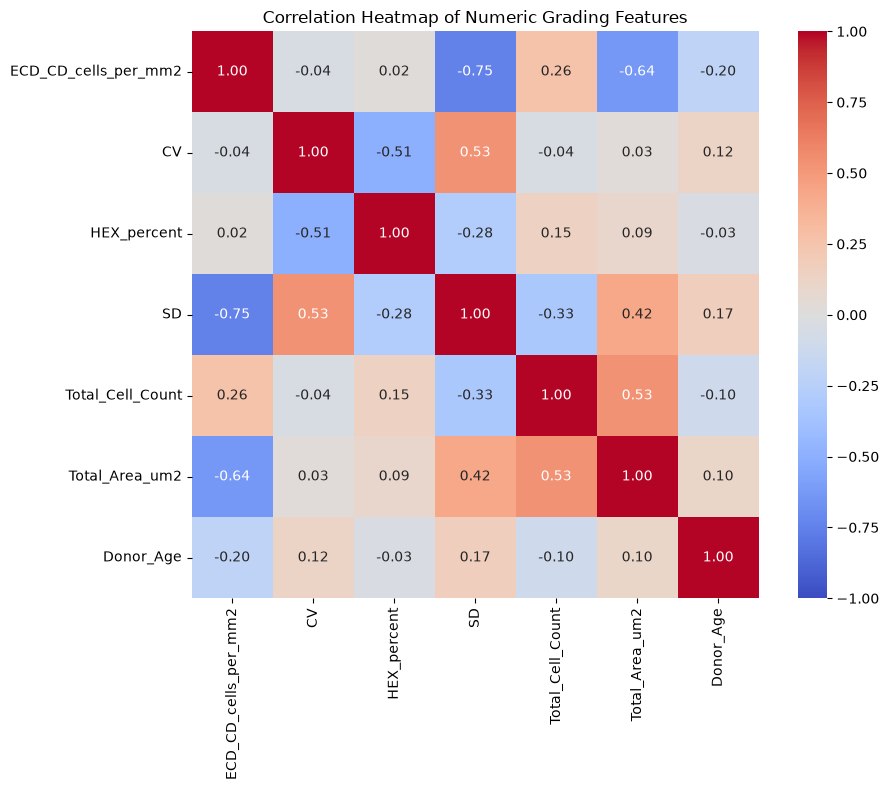

In [13]:

import matplotlib.pyplot as plt
import seaborn as sns

correlation_features = [
    "ECD_CD_cells_per_mm2",
    "CV",
    "HEX_percent",
    "SD",
    "Total_Cell_Count",
    "Total_Area_um2",
    "Donor_Age",
]

correlation_matrix = df[correlation_features].corr(
    method="pearson"
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
)

plt.title("Correlation Heatmap of Numeric Grading Features")
plt.tight_layout()
plt.show()


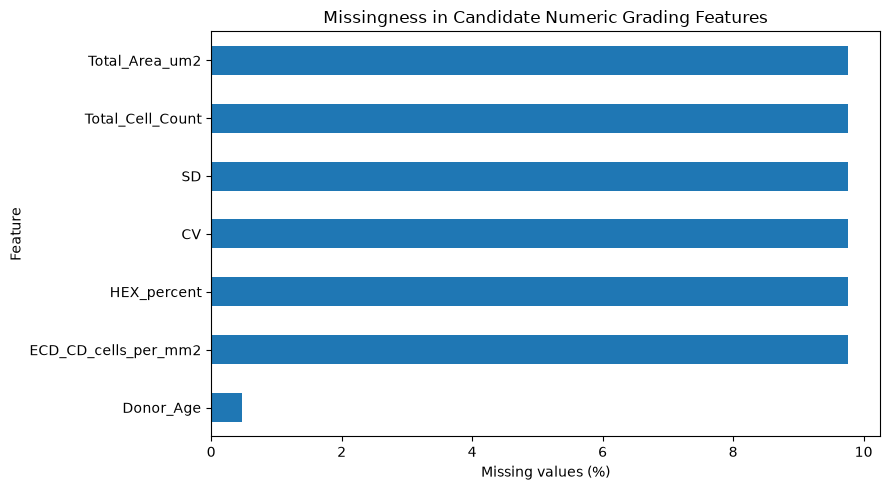

In [14]:

missing_pct = (
    df[numeric_features]
    .isna()
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(9, 5))
missing_pct.plot(kind="barh")

plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.title("Missingness in Candidate Numeric Grading Features")
plt.tight_layout()
plt.show()


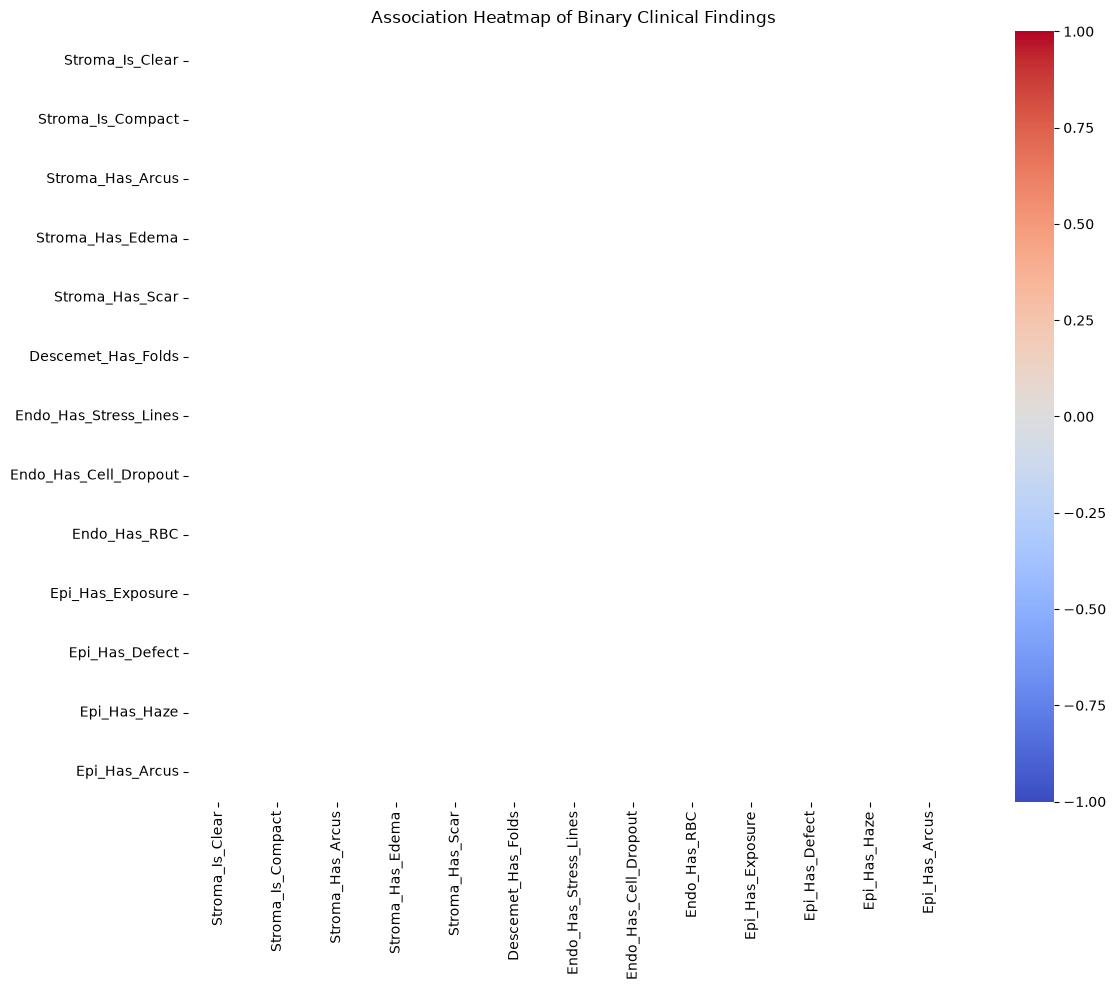

In [15]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

binary_clinical_features = [
    "Stroma_Is_Clear",
    "Stroma_Is_Compact",
    "Stroma_Has_Arcus",
    "Stroma_Has_Edema",
    "Stroma_Has_Scar",
    "Descemet_Has_Folds",
    "Endo_Has_Stress_Lines",
    "Endo_Has_Cell_Dropout",
    "Endo_Has_RBC",
    "Epi_Has_Exposure",
    "Epi_Has_Defect",
    "Epi_Has_Haze",
    "Epi_Has_Arcus",
]

# Convert booleans to numeric values.
# Retain missing values; do not treat them as absence.
binary_df = df[binary_clinical_features].copy()

for col in binary_clinical_features:
    binary_df[col] = binary_df[col].map({
        True: 1,
        False: 0,
        1: 1,
        0: 0,
    })

clinical_corr = binary_df.corr(method="pearson")

plt.figure(figsize=(13, 10))
sns.heatmap(
    clinical_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
)
plt.title("Association Heatmap of Binary Clinical Findings")
plt.tight_layout()
plt.show()


In [16]:

print("Original values:")
for col in binary_clinical_features:
    print(f"{col}: {df[col].value_counts(dropna=False).to_dict()}")

print("\nConverted values:")
print(binary_df.head())

print("\nNon-missing values per feature:")
print(binary_df.notna().sum())

print("\nCorrelation matrix:")
print(binary_df.corr().round(2))


Original values:
Stroma_Is_Clear: {1.0: 577, nan: 467, 0.0: 11}
Stroma_Is_Compact: {nan: 467, 0.0: 358, 1.0: 230}
Stroma_Has_Arcus: {1.0: 486, nan: 467, 0.0: 102}
Stroma_Has_Edema: {0.0: 578, nan: 467, 1.0: 10}
Stroma_Has_Scar: {0.0: 555, nan: 467, 1.0: 33}
Descemet_Has_Folds: {1.0: 535, nan: 511, 0.0: 9}
Endo_Has_Stress_Lines: {1.0: 499, nan: 480, 0.0: 76}
Endo_Has_Cell_Dropout: {0.0: 482, nan: 480, 1.0: 93}
Endo_Has_RBC: {0.0: 545, nan: 480, 1.0: 30}
Epi_Has_Exposure: {nan: 468, 1.0: 316, 0.0: 271}
Epi_Has_Defect: {0.0: 583, nan: 468, 1.0: 4}
Epi_Has_Haze: {0.0: 555, nan: 468, 1.0: 32}
Epi_Has_Arcus: {nan: 468, 1.0: 328, 0.0: 259}

Converted values:
   Stroma_Is_Clear  Stroma_Is_Compact  Stroma_Has_Arcus  Stroma_Has_Edema  \
0              NaN                NaN               NaN               NaN   
1              NaN                NaN               NaN               NaN   
2              NaN                NaN               NaN               NaN   
3              NaN              

In [17]:

# Recreate the dataframe directly from the original cleaned columns
binary_df = df[binary_clinical_features].copy()

# Convert values to numeric without losing valid 0s and 1s
binary_df = binary_df.apply(
    lambda col: pd.to_numeric(col, errors="coerce")
)

print("Non-missing values per feature:")
print(binary_df.notna().sum())

print("\nUnique values per feature:")
print(binary_df.nunique(dropna=True))


Non-missing values per feature:
Stroma_Is_Clear          588
Stroma_Is_Compact        588
Stroma_Has_Arcus         588
Stroma_Has_Edema         588
Stroma_Has_Scar          588
Descemet_Has_Folds       544
Endo_Has_Stress_Lines    575
Endo_Has_Cell_Dropout    575
Endo_Has_RBC             575
Epi_Has_Exposure         587
Epi_Has_Defect           587
Epi_Has_Haze             587
Epi_Has_Arcus            587
dtype: int64

Unique values per feature:
Stroma_Is_Clear          2
Stroma_Is_Compact        2
Stroma_Has_Arcus         2
Stroma_Has_Edema         2
Stroma_Has_Scar          2
Descemet_Has_Folds       2
Endo_Has_Stress_Lines    2
Endo_Has_Cell_Dropout    2
Endo_Has_RBC             2
Epi_Has_Exposure         2
Epi_Has_Defect           2
Epi_Has_Haze             2
Epi_Has_Arcus            2
dtype: int64


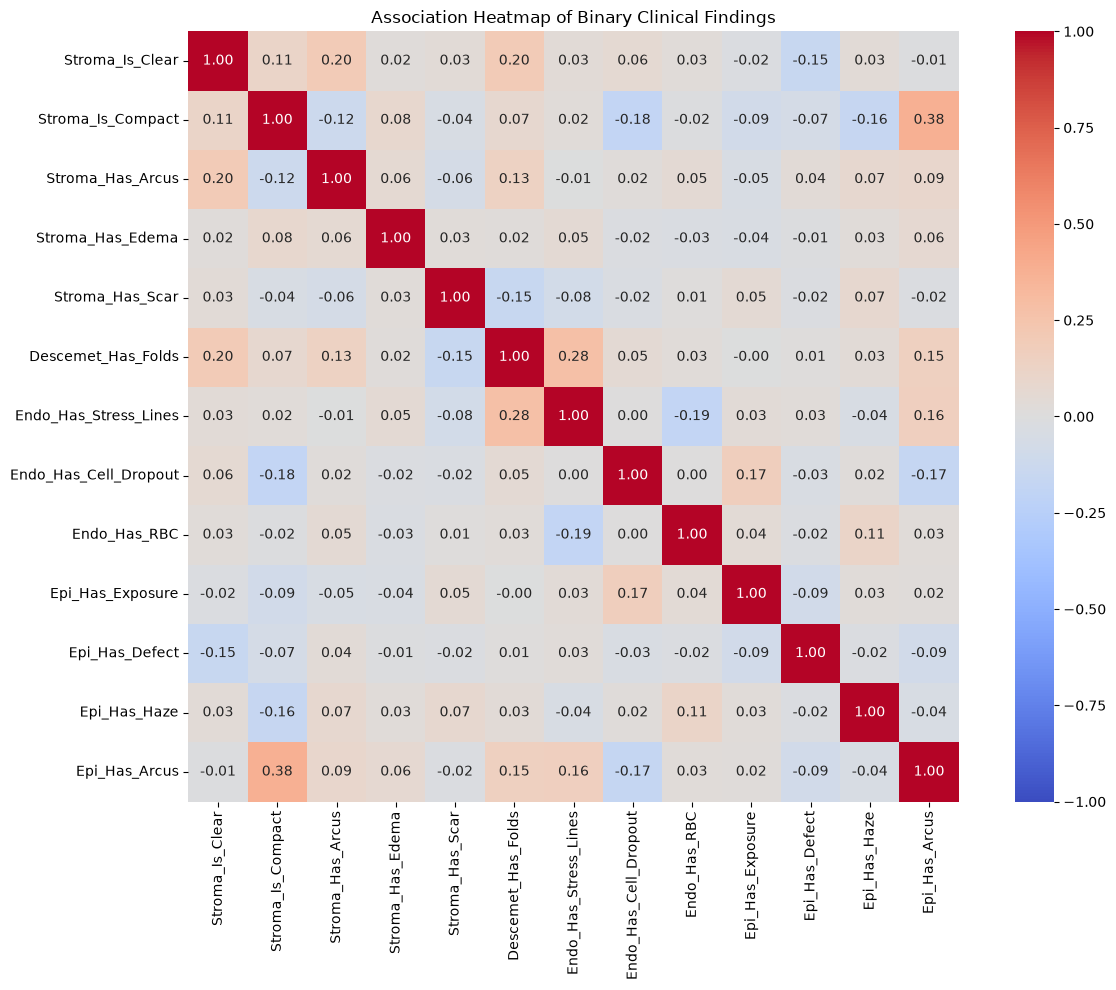

In [18]:

clinical_corr = binary_df.corr(method="pearson")

plt.figure(figsize=(13, 10))

sns.heatmap(
    clinical_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    square=True,
)

plt.title("Association Heatmap of Binary Clinical Findings")
plt.tight_layout()
plt.show()


In [19]:

categorical_clinical_features = [
    "Stroma_Arcus_Severity",
    "Stroma_Scar_Type",
    "Descemet_Fold_Severity",
    "Descemet_Fold_Relative_Number",
    "Endo_Stress_Line_Location",
    "Endo_Stress_Line_Amount",
    "Endo_Cell_Dropout_Severity",
    "Endo_RBC_Severity",
    "Epi_Exposure_Severity",
    "Epi_Exposure_Location",
    "Epi_Haze_Severity",
]

for feature in categorical_clinical_features:
    print(f"\n--- {feature} ---")
    print(df[feature].value_counts(dropna=False))



--- Stroma_Arcus_Severity ---
Stroma_Arcus_Severity
NaN            569
Unspecified    437
Mild            43
Moderate         6
Name: count, dtype: int64

--- Stroma_Scar_Type ---
Stroma_Scar_Type
NaN           1022
Other scar      27
Phaco scar       6
Name: count, dtype: int64

--- Descemet_Fold_Severity ---
Descemet_Fold_Severity
NaN            511
Mild           387
Unspecified    118
Moderate        21
Very mild       18
Name: count, dtype: int64

--- Descemet_Fold_Relative_Number ---
Descemet_Fold_Relative_Number
NaN                 511
Unspecified         261
Mild                252
Several              28
Moderate              2
Several/Moderate      1
Name: count, dtype: int64

--- Endo_Stress_Line_Location ---
Endo_Stress_Line_Location
NaN                     543
Central                 243
Unspecified             174
Peripheral               67
Central + Peripheral     28
Name: count, dtype: int64

--- Endo_Stress_Line_Amount ---
Endo_Stress_Line_Amount
NaN            556
F

In [20]:

categorical_candidates = [
    "Descemet_Fold_Severity",
    "Descemet_Fold_Relative_Number",
    "Endo_Stress_Line_Location",
    "Epi_Exposure_Severity",
    "Epi_Exposure_Location",
    "Stroma_Arcus_Severity",
]

grade_df = df[
    df["Tissue_Grade_Clean"].isin(["A+", "A", "B"])
].copy()

for feature in categorical_candidates:
    print(f"\n--- {feature} ---")

    counts = pd.crosstab(
        grade_df["Tissue_Grade_Clean"],
        grade_df[feature],
        dropna=False,
    )

    print("Counts:")
    print(counts)

    print("\nRow percentages:")
    print(
        pd.crosstab(
            grade_df["Tissue_Grade_Clean"],
            grade_df[feature],
            normalize="index",
            dropna=False,
        ).mul(100).round(1)
    )



--- Descemet_Fold_Severity ---
Counts:
Descemet_Fold_Severity  Mild  Moderate  Unspecified  Very mild  NaN
Tissue_Grade_Clean                                                 
A                        136         9           35          2  137
A+                       200         1           56         13  275
B                         48        11           16          2   95

Row percentages:
Descemet_Fold_Severity  Mild  Moderate  Unspecified  Very mild   NaN
Tissue_Grade_Clean                                                  
A                       42.6       2.8         11.0        0.6  42.9
A+                      36.7       0.2         10.3        2.4  50.5
B                       27.9       6.4          9.3        1.2  55.2

--- Descemet_Fold_Relative_Number ---
Counts:
Descemet_Fold_Relative_Number  Mild  Moderate  Several  Several/Moderate  \
Tissue_Grade_Clean                                                         
A                                91         0       14    

In [21]:

feature = "Stroma_Arcus_Severity"

recorded = grade_df.dropna(subset=[feature])

print("Recorded observations only — row percentages:")

print(
    pd.crosstab(
        recorded["Tissue_Grade_Clean"],
        recorded[feature],
        normalize="index",
    ).mul(100).round(1)
)


Recorded observations only — row percentages:
Stroma_Arcus_Severity  Mild  Moderate  Unspecified
Tissue_Grade_Clean                                
A                       9.5       1.2         89.3
A+                      5.9       0.4         93.7
B                      11.6       2.9         85.5


In [22]:

remaining_features = [
    "Descemet_Fold_Severity",
    "Descemet_Fold_Relative_Number",
    "Endo_Stress_Line_Location",
    "Epi_Exposure_Severity",
    "Epi_Exposure_Location",
]

for feature in remaining_features:
    recorded = grade_df.dropna(subset=[feature])

    print(f"\n--- {feature} ---")
    print("Recorded counts:")
    print(pd.crosstab(
        recorded["Tissue_Grade_Clean"],
        recorded[feature],
    ))

    print("\nRecorded row percentages:")
    print(
        pd.crosstab(
            recorded["Tissue_Grade_Clean"],
            recorded[feature],
            normalize="index",
        ).mul(100).round(1)
    )



--- Descemet_Fold_Severity ---
Recorded counts:
Descemet_Fold_Severity  Mild  Moderate  Unspecified  Very mild
Tissue_Grade_Clean                                            
A                        136         9           35          2
A+                       200         1           56         13
B                         48        11           16          2

Recorded row percentages:
Descemet_Fold_Severity  Mild  Moderate  Unspecified  Very mild
Tissue_Grade_Clean                                            
A                       74.7       4.9         19.2        1.1
A+                      74.1       0.4         20.7        4.8
B                       62.3      14.3         20.8        2.6

--- Descemet_Fold_Relative_Number ---
Recorded counts:
Descemet_Fold_Relative_Number  Mild  Moderate  Several  Several/Moderate  \
Tissue_Grade_Clean                                                         
A                                91         0       14                 0   
A+        

In [24]:

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

categorical_candidates = [
    "Stroma_Arcus_Severity",
    "Descemet_Fold_Severity",
    "Descemet_Fold_Relative_Number",
    "Endo_Stress_Line_Location",
    "Epi_Exposure_Severity",
    "Epi_Exposure_Location",
]

target = "Tissue_Grade_Clean"
grade_df = df[df[target].isin(["A+", "A", "B"])].copy()

results = []

for feature in categorical_candidates:
    # Exclude missing values but retain "Unspecified"
    subset = grade_df[[target, feature]].dropna()

    table = pd.crosstab(subset[target], subset[feature])

    if min(table.shape) < 2:
        continue

    chi2, p_value, dof, expected = chi2_contingency(
        table,
        correction=False
    )

    n = table.to_numpy().sum()
    r, k = table.shape

    # Bias-corrected Cramer's V
    phi2 = chi2 / n
    phi2_corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(r_corr - 1, k_corr - 1)
    cramer_v = (
        np.sqrt(phi2_corr / denominator)
        if denominator > 0 else np.nan
    )

    results.append({
        "Feature": feature,
        "N": n,
        "Categories": k,
        "Cramers_V": cramer_v,
        "Chi_square_p": p_value,
        "Min_expected_count": expected.min(),
        "Expected_cells_below_5": int((expected < 5).sum()),
    })

association_results = pd.DataFrame(results).sort_values(
    "Cramers_V",
    ascending=False
)

print(association_results.round(4))

                         Feature    N  Categories  Cramers_V  Chi_square_p  \
2  Descemet_Fold_Relative_Number  529           5     0.1747        0.0000   
1         Descemet_Fold_Severity  529           4     0.1690        0.0000   
0          Stroma_Arcus_Severity  475           3     0.0512        0.1655   
3      Endo_Stress_Line_Location  501           4     0.0442        0.2407   
5          Epi_Exposure_Location  307           4     0.0278        0.3706   
4          Epi_Exposure_Severity  307           3     0.0000        0.9109   

   Min_expected_count  Expected_cells_below_5  
2              0.1456                       7  
1              2.4745                       2  
0              0.7263                       3  
3              3.6108                       1  
5              0.7003                       3  
4              2.2410                       1  


In [25]:

for feature in [
    "Descemet_Fold_Relative_Number",
    "Descemet_Fold_Severity",
]:
    subset = grade_df[[target, feature]].dropna()

    print(f"\n--- {feature} ---")
    print("Observed counts:")
    print(pd.crosstab(subset[target], subset[feature]))

    print("\nExpected counts under independence:")
    observed = pd.crosstab(subset[target], subset[feature])
    _, _, _, expected = chi2_contingency(
        observed,
        correction=False
    )

    print(pd.DataFrame(
        expected,
        index=observed.index,
        columns=observed.columns,
    ).round(2))



--- Descemet_Fold_Relative_Number ---
Observed counts:
Descemet_Fold_Relative_Number  Mild  Moderate  Several  Several/Moderate  \
Tissue_Grade_Clean                                                         
A                                91         0       14                 0   
A+                              123         0        3                 1   
B                                35         2       11                 0   

Descemet_Fold_Relative_Number  Unspecified  
Tissue_Grade_Clean                          
A                                       77  
A+                                     143  
B                                       29  

Expected counts under independence:
Descemet_Fold_Relative_Number    Mild  Moderate  Several  Several/Moderate  \
Tissue_Grade_Clean                                                           
A                               85.67      0.69     9.63              0.34   
A+                             127.09      1.02    14.29           

In [26]:

from scipy.stats import chi2_contingency

for feature in [
    "Descemet_Fold_Relative_Number",
    "Descemet_Fold_Severity",
]:
    subset = grade_df[[target, feature]].dropna()
    table = pd.crosstab(subset[target], subset[feature])

    # Monte Carlo approximation to the chi-square test
    result = chi2_contingency(
        table,
        correction=False,
        method=__import__(
            "scipy.stats", fromlist=["MonteCarloMethod"]
        ).MonteCarloMethod(n_resamples=9999, rng=__import__("numpy").random.default_rng(42))
    )

    print(f"\n{feature}")
    print("N:", table.to_numpy().sum())
    print("Chi-square statistic:", round(result.statistic, 4))
    print("Monte Carlo p-value:", round(result.pvalue, 5))



Descemet_Fold_Relative_Number
N: 529
Chi-square statistic: 40.1871
Monte Carlo p-value: 0.0001

Descemet_Fold_Severity
N: 529
Chi-square statistic: 36.1146
Monte Carlo p-value: 0.0003


In [28]:

import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, MonteCarloMethod

categorical_candidates = [
    "Stroma_Arcus_Severity",
    "Descemet_Fold_Severity",
    "Descemet_Fold_Relative_Number",
    "Endo_Stress_Line_Location",
    "Epi_Exposure_Severity",
    "Epi_Exposure_Location",
]

target = "Tissue_Grade_Clean"

grade_df = df[
    df[target].isin(["A+", "A", "B"])
].copy()

results = []

for i, feature in enumerate(categorical_candidates):
    subset = grade_df[[target, feature]].dropna()
    table = pd.crosstab(subset[target], subset[feature])

    if min(table.shape) < 2:
        continue

    chi2, p_value, dof, expected = chi2_contingency(
        table,
        correction=False,
        method=MonteCarloMethod(
            n_resamples=9999,
            rng=np.random.default_rng(42 + i),
        ),
    )

    n = table.to_numpy().sum()
    r, k = table.shape

    # Bias-corrected Cramer's V
    phi2 = chi2 / n
    phi2_corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1),
    )
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(r_corr - 1, k_corr - 1)
    cramer_v = (
        np.sqrt(phi2_corr / denominator)
        if denominator > 0 else np.nan
    )

    results.append({
        "Feature": feature,
        "N": n,
        "Cramers_V": cramer_v,
        "Chi_square_p": p_value,
        "Min_expected_count": expected.min(),
        "Expected_cells_below_5": int((expected < 5).sum()),
    })

association_results = pd.DataFrame(results)

# Holm multiple-comparison correction
p_values = association_results["Chi_square_p"].to_numpy()
m = len(p_values)
order = np.argsort(p_values)
adjusted = np.empty(m)

sorted_adjusted = np.maximum.accumulate(
    np.array([
        min(1.0, (m - rank) * p_values[index])
        for rank, index in enumerate(order)
    ])
)

adjusted[order] = sorted_adjusted

association_results["Holm_adjusted_p"] = adjusted
association_results["Significant_Holm_0.05"] = (
    association_results["Holm_adjusted_p"] < 0.05
)

association_results = association_results.sort_values(
    "Holm_adjusted_p"
)

print(association_results.round(4))


                         Feature    N  Cramers_V  Chi_square_p  \
1         Descemet_Fold_Severity  529     0.1690        0.0001   
2  Descemet_Fold_Relative_Number  529     0.1747        0.0001   
0          Stroma_Arcus_Severity  475     0.0512        0.1539   
3      Endo_Stress_Line_Location  501     0.0442        0.2375   
5          Epi_Exposure_Location  307     0.0278        0.3735   
4          Epi_Exposure_Severity  307     0.0000        0.9166   

   Min_expected_count  Expected_cells_below_5  Holm_adjusted_p  \
1              2.4745                       2           0.0006   
2              0.1456                       7           0.0006   
0              0.7263                       3           0.6156   
3              3.6108                       1           0.7125   
5              0.7003                       3           0.7470   
4              2.2410                       1           0.9166   

   Significant_Holm_0.05  
1                   True  
2                   